Configuração e Importações

"Para executar o notebook, faça o upload dos arquivos employees.csv, training_records.csv, ai_usage_logs.csv e security_events.csv na raiz do ambiente de arquivos do Colab."

In [ ]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# leitura e junção dos dados
employees = pd.read_csv("employees.csv")
training_records = pd.read_csv("training_records.csv")
ai_usage = pd.read_csv("ai_usage_logs.csv")
security = pd.read_csv("security_events.csv")

treinos = training_records[training_records['completion_status'] == 'Concluido'].groupby('employee_id').size().reset_index(name='cursos_concluidos')
uso = ai_usage.groupby('employee_id').agg(total_tokens=('input_tokens', 'sum')).reset_index()
risco = security.groupby('employee_id').size().reset_index(name='incidentes')

df = employees.merge(treinos, on='employee_id', how='left') \
              .merge(uso, on='employee_id', how='left') \
              .merge(risco, on='employee_id', how='left')

# tratamento estrutural e criação do alvo
df['incidentes'] = df['incidentes'].fillna(0)
df['teve_incidente'] = (df['incidentes'] > 0).astype(int)

# separação das variáveis
X = df[['seniority', 'department_id', 'cursos_concluidos', 'total_tokens']]
y = df['teve_incidente']

Pipeline e Divisão

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

num_cols = ['cursos_concluidos', 'total_tokens']
p_num = Pipeline([
    ("imp", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler())
])

cat_cols = ['department_id']
p_cat = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01))
])

ord_cols = ['seniority']
ordem = ['Junior', 'Pleno', 'Senior', 'Especialista', 'Diretor']
p_ord = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(categories=[ordem], handle_unknown="use_encoded_value", unknown_value=-1))
])

pre = ColumnTransformer([
    ("num", p_num, num_cols),
    ("cat", p_cat, cat_cols),
    ("ord", p_ord, ord_cols)
])

Treinamento e Validação

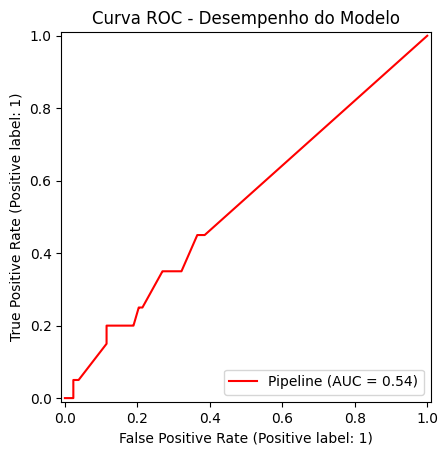

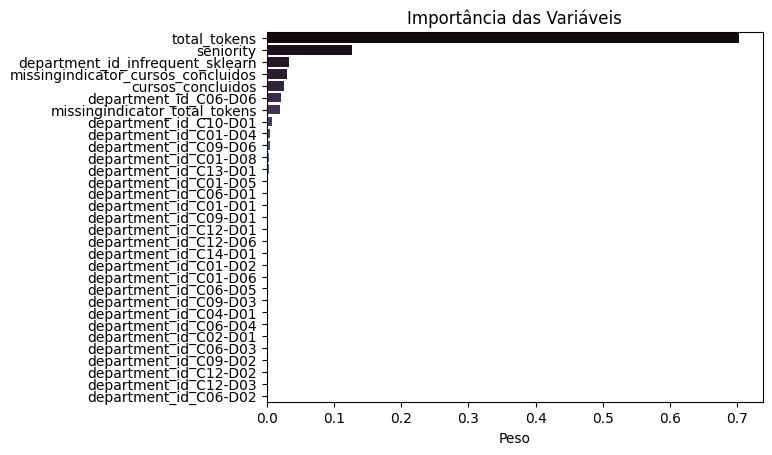

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(modelo, X_test, y_test, color='red')
plt.title('Curva ROC - Desempenho do Modelo')
plt.show() # Mostra o primeiro gráfico e limpa a tela

#nomes e os pesos gerados
nomes = modelo.named_steps['pre'].get_feature_names_out()
pesos = modelo.named_steps['clf'].feature_importances_

#limpa os nomes
nomes_limpos = [nome.split('__')[-1] for nome in nomes]

#tabelinha
df_imp = pd.DataFrame({'Variavel': nomes_limpos, 'Peso': pesos})
df_imp = df_imp.sort_values(by='Peso', ascending=False)

#plota com o seaborn
sns.barplot(data=df_imp, x='Peso', y='Variavel', palette='mako')
plt.title('Importância das Variáveis')
plt.ylabel('') # Tira o rótulo lateral para ficar mais limpo
plt.show()